# 12 - bullet deflection: testing the shear idea

In the Wax & Wayne books, bullets crossing a speed bubble boundary get
deflected; Wayne bets his life on it. Notebook 07 proved the when-not-where
theorem: a bubble changes when a point-sized body arrives, never where its
path goes. A point cannot be deflected. That leaves shear, which for this
notebook means: the two ends of a body being dragged at different rates
because they sit in different time zones. A bullet has length, so while it
crosses the boundary its nose and tail briefly live at different speeds,
and the rigid connection between them has to do something about it.

Terms used in this notebook, defined once:

- **Stored velocity**: the number in `body.velocity` - meters per second of
  the body's own experienced time.
- **Outside-clock speed**: what an observer outside the bubble measures:
  stored velocity times the bubble's factor.
- **Half-in**: the stretch of ticks when part of the body is inside the
  bubble and the rest is still outside.
- **Heading**: the direction of travel, in degrees. A heading change is a
  turn.
- **Tilt**: the angle between the bullet's long axis and its direction of
  motion. Zero tilt = flying nose-first.
- **Spin**: how fast the body rotates, in degrees per second.
- **Ground truth**: the slow, careful version of an experiment, run once to
  check the fast version against. Ours is built from stiff springs, because
  springs use only force rules the engine already has.
- **Tick-rate sweep**: the same experiment run with smaller and smaller time
  steps. If the answer settles, it is real. If it keeps moving, it is the
  time step talking.

History of this notebook, recorded plainly. The first draft (Gemini,
2026-06-10) built the two-point bullet, correctly found that at 240 Hz a
fast bullet skips the boundary inside one tick, raised the tick rate, saw a
3.57 m trajectory difference, and concluded the deflection was real. Part 1
shows that number was two errors stacked: a control that the when-not-where
theorem rules out, and a constraint that added energy at every crossing -
at the draft's own tick rate, the bullet actually came back out the side it
entered, reversed. This is the project's fourth confirmed wrong-but-plausible
result, after the trajectory-dip narration, the spawn-tick friction bug, and
the oscillating-coin metric.

One thing in the draft's output was real, and Elliott spotted it in the
draft's experiment-B plot: the nose and tail traces separate after the
bubble, which means the bullet came out rotating. That observation survives
everything below. The boundary cannot turn an aligned bullet's path, but it
spins a tilted one - and a spinning bullet in air would lose its line. Air
is not modeled yet; that is the missing piece, recorded in the findings.

Plan: part 1, what was wrong with the first draft. Part 2, ground truth for
what a rigid rod does at a boundary. Part 3, the corrected constraint and
the slow-down rule. Part 4, the tilted bullet.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, SpeedBubble, RigidConstraint, GRAVITY_M_PER_S2

BULLET_LENGTH_M = 0.2
BULLET_MASS_KG = 0.02   # 10 g per end
LAUNCH_SPEED = 50.0
BUBBLE = dict(center=(10, 10), radius_m=5, time_factor=5.0)


class AntiGravity:
    """Cancels gravity for the given bodies. Outside bubbles a bullet then
    flies dead straight, so its heading becomes a clean signal: any change
    at all was caused by the bubble boundary and nothing else."""

    def __init__(self, bodies):
        self.bodies = bodies

    def apply_forces(self):
        for body in self.bodies:
            body.apply_force([0.0, GRAVITY_M_PER_S2 * body.mass_kg])


def make_bullet(world, center, flight_deg, speed, tilt_deg=0.0,
                constraint_class=RigidConstraint):
    """Two point masses joined by a rigid rod. flight_deg sets the velocity
    direction; tilt_deg tilts the rod RELATIVE to the velocity (0 = flying
    nose-first)."""
    flight = np.radians(flight_deg)
    rod = np.radians(flight_deg + tilt_deg)
    flight_direction = np.array([np.cos(flight), np.sin(flight)])
    rod_direction = np.array([np.cos(rod), np.sin(rod)])
    center = np.asarray(center, dtype=float)

    nose = world.add_body(Body("nose", BULLET_MASS_KG / 2,
                               center + rod_direction * BULLET_LENGTH_M / 2,
                               velocity=flight_direction * speed, radius_m=0.01))
    tail = world.add_body(Body("tail", BULLET_MASS_KG / 2,
                               center - rod_direction * BULLET_LENGTH_M / 2,
                               velocity=flight_direction * speed, radius_m=0.01))
    world.add_power(constraint_class(nose, tail, BULLET_LENGTH_M))
    return nose, tail


def heading_deg(velocity):
    return np.degrees(np.arctan2(velocity[1], velocity[0]))


def bullet_state(nose, tail):
    """Center-of-mass heading and speed, plus the tumble rate: the part of
    the ends' relative velocity that rotates the rod, in degrees per second."""
    center_of_mass_velocity = (nose.velocity + tail.velocity) / 2
    relative = nose.velocity - tail.velocity
    rod = nose.position - tail.position
    rod = rod / np.linalg.norm(rod)
    tangential = relative - np.dot(relative, rod) * rod
    spin_deg_per_s = np.degrees(np.linalg.norm(tangential) / BULLET_LENGTH_M)
    return (heading_deg(center_of_mass_velocity), float(np.linalg.norm(center_of_mass_velocity)),
            spin_deg_per_s)


def cross_bubble(constraint_class, hz, time_factor=5.0, flight_deg=15.0,
                 tilt_deg=0.0, spawn_shift_m=0.0, max_seconds=4.0):
    """Fire a gravity-free bullet through the bubble and report its state
    once it is done with the bubble. Returns (heading change from launch,
    exit speed, exit spin)."""
    world = World(dt_seconds=1.0 / hz)
    flight_direction = np.array([np.cos(np.radians(flight_deg)),
                                 np.sin(np.radians(flight_deg))])
    center = np.array([0.0, 10.0]) + flight_direction * spawn_shift_m
    nose, tail = make_bullet(world, center, flight_deg, LAUNCH_SPEED,
                             tilt_deg=tilt_deg, constraint_class=constraint_class)
    world.add_power(AntiGravity([nose, tail]))
    world.add_bubble(SpeedBubble(**dict(BUBBLE, time_factor=time_factor)))
    bubble_center = np.array(BUBBLE["center"], dtype=float)

    # 'Done with the bubble' = both ends well outside it and the bullet
    # receding. That covers the normal pass-through AND the old rule's
    # failure case, where the bullet comes back out the side it entered.
    for _ in range(int(max_seconds * hz)):
        world.step()
        center_of_mass_position = (nose.position + tail.position) / 2
        center_of_mass_velocity = (nose.velocity + tail.velocity) / 2
        clear_of_bubble = all(
            np.linalg.norm(body.position - bubble_center) > 5.2
            for body in (nose, tail))
        receding = np.dot(center_of_mass_velocity, center_of_mass_position - bubble_center) > 0
        if clear_of_bubble and receding:
            break
    else:
        raise RuntimeError("bullet never cleared the bubble")

    heading, speed, spin = bullet_state(nose, tail)
    return heading - flight_deg, speed, spin

## Part 1 - what was wrong with the first draft

The draft's main experiment compared a bubbled bullet against a no-bubble
control at the same clock time, and read the 3.57 m gap as deflection. Each
ingredient has a separate problem.

**Wrong control.** By the when-not-where theorem, a bubble reschedules a
point body along an unchanged path. The bubbled bullet crosses 10 m of
bubble in a fifth of the time, so at any fixed clock reading it is simply
further along the same curve - higher and faster, with no turning anywhere.
The right control for "did the rod do anything?" is a point body through
the same bubble. The draft's intro cites the theorem; its experiment design
does not apply it.

**Wrong correction rule.** The draft's constraint split position
corrections by mass and divided each end's velocity correction by that
end's local time step. Across a boundary, that gives the bigger velocity
change to the end OUTSIDE the bubble. The engine's own rule for internal
force pairs - the one steelpush is built on - gives the bigger change to
the end that experiences more time: the end INSIDE. The draft's rule is
backwards relative to the engine's physics, and it is not conservative: it
adds speed at every crossing.

The draft's constraint is kept below, unchanged, for the record.


In [2]:
class OldRigidConstraint:
    """The first draft's projection, kept for the record: position
    corrections shared by inverse mass, velocity corrections divided by each
    body's LOCAL dt - an equal-and-opposite IMPULSE convention. Fine outside
    bubbles (it reduces to the same thing); wrong across a boundary."""

    def __init__(self, body_a, body_b, length_m):
        self.body_a = body_a
        self.body_b = body_b
        self.length_m = float(length_m)

    def tick(self, dt_seconds):
        offset = self.body_a.position - self.body_b.position
        distance = float(np.linalg.norm(offset))
        if distance < 1e-9:
            return
        direction = offset / distance
        error = distance - self.length_m
        if abs(error) < 1e-12:
            return
        total_mass = self.body_a.mass_kg + self.body_b.mass_kg
        correction_a = -(self.body_b.mass_kg / total_mass) * error * direction
        correction_b = (self.body_a.mass_kg / total_mass) * error * direction
        self.body_a.position += correction_a
        self.body_b.position += correction_b
        local_dt_a = self.body_a.local_dt_seconds or dt_seconds
        local_dt_b = self.body_b.local_dt_seconds or dt_seconds
        self.body_a.velocity += correction_a / local_dt_a
        self.body_b.velocity += correction_b / local_dt_b


# The draft's headline experiment, rerun exactly (2000 Hz, 10 deg launch,
# gravity on, final nose height at t = 0.5 s) - plus the null it was missing.
def final_nose_height(with_bubble, with_rod):
    world = World(dt_seconds=1.0 / 2000.0)
    if with_rod:
        nose, _ = make_bullet(world, (0, 10), flight_deg=10, speed=LAUNCH_SPEED,
                              constraint_class=OldRigidConstraint)
    else:
        direction = np.array([np.cos(np.radians(10)), np.sin(np.radians(10))])
        nose = world.add_body(Body("nose", BULLET_MASS_KG,
                                   direction * 0.1 + [0, 10],
                                   velocity=direction * LAUNCH_SPEED, radius_m=0.01))
    if with_bubble:
        world.add_bubble(SpeedBubble(**BUBBLE))
    world.run(0.5)
    return nose.position[1]


control = final_nose_height(with_bubble=False, with_rod=True)
bubbled_rod = final_nose_height(with_bubble=True, with_rod=True)
bubbled_point = final_nose_height(with_bubble=True, with_rod=False)

print(f"no-bubble control, final y:            {control:8.4f} m")
print(f"bubbled rigid bullet, final y:         {bubbled_rod:8.4f} m")
print(f"bubbled POINT MASS, final y:           {bubbled_point:8.4f} m   (no rod, no shear possible)")
print()
print(f"the draft's 'deflection':              {bubbled_rod - control:8.4f} m")
print(f"scheduling alone (when-not-where):     {bubbled_point - control:8.4f} m")
print(f"left to explain:                       {bubbled_rod - bubbled_point:8.4f} m")

no-bubble control, final y:             13.1311 m
bubbled rigid bullet, final y:          16.7022 m
bubbled POINT MASS, final y:            13.5942 m   (no rod, no shear possible)

the draft's 'deflection':                3.5711 m
scheduling alone (when-not-where):       0.4631 m
left to explain:                         3.1080 m


Half a metre of the 3.57 is the theorem the draft already knew. The
remaining 3.1 m needs a better instrument than "height at a fixed clock
time," because that measure cannot tell a turned bullet from a faster one -
a faster bullet flies flatter and sits higher at every x.

So: cancel gravity. A gravity-free point body exits the bubble with heading
and speed exactly unchanged (when-not-where; verified below to six
decimals). Whatever the rigid bullet's heading and speed do is then
entirely the boundary's work. We sweep the tick rate - the draft picked
2000 Hz because that is where its effect appeared, which is backwards: an
effect visible at only one tick rate belongs to the tick rate. And we shift
the spawn point by sub-tick fractions, because real physics cannot care
where the tick boundaries fall.


In [3]:
print("OLD constraint, gravity-free, 15 deg launch through the 5x bubble")
print("(a clean crossing would change heading by 0 and leave speed at 50)")
print()
print(f"{'tick rate':>10}  {'heading change':>15}  {'exit speed':>11}")
for hz in [500, 1000, 2000, 4000, 8000]:
    turn, speed, _ = cross_bubble(OldRigidConstraint, hz)
    print(f"{hz:9d}Hz  {turn:+14.4f} deg  {speed:9.2f} m/s")

print()
print("spawn-point shifts at 2000 Hz (shifting the start point by fractions")
print("of one tick's travel - real physics would not care):")
travel_per_tick = LAUNCH_SPEED / 2000.0
for fraction in [0.0, 0.25, 0.5, 0.75]:
    turn, speed, _ = cross_bubble(OldRigidConstraint, 2000,
                                  spawn_shift_m=fraction * travel_per_tick)
    print(f"  shift {fraction:4.2f} tick: heading change {turn:+9.4f} deg, exit speed {speed:7.2f} m/s")

OLD constraint, gravity-free, 15 deg launch through the 5x bubble
(a clean crossing would change heading by 0 and leave speed at 50)

 tick rate   heading change   exit speed
      500Hz         -0.0000 deg      90.00 m/s
     1000Hz         -0.0000 deg      90.00 m/s
     2000Hz       -180.0000 deg      97.20 m/s
     4000Hz         +0.0000 deg     162.00 m/s
     8000Hz         +0.0000 deg     162.00 m/s

spawn-point shifts at 2000 Hz (shifting the start point by fractions
of one tick's travel - real physics would not care):
  shift 0.00 tick: heading change -180.0000 deg, exit speed   97.20 m/s
  shift 0.25 tick: heading change -180.0000 deg, exit speed   97.20 m/s
  shift 0.50 tick: heading change -180.0000 deg, exit speed   97.20 m/s
  shift 0.75 tick: heading change -180.0000 deg, exit speed   97.20 m/s


What the table says. The draft's constraint never turns the bullet at any
tick rate - the heading change is zero everywhere the run stays sane. It
adds speed instead: 1.8x per crossing, 3.24x for in-and-out. And at
2000 Hz, the draft's own tick rate, the crossing breaks: the tail gets a
one-tick velocity change so large that it travels clear past the nose
between ticks, the rod turns inside-out, and the bullet leaves backwards at
97 m/s - flipping between that and a normal pass as the spawn point shifts
by less than one tick of travel. The draft's 3.57 m was rescheduling plus
added speed, read through a measure that cannot tell either from a turn.

What the draft got right, also for the record: the one-tick skip at 240 Hz
is real (per-tick travel exceeds the rod length), projection instead of
springs is the right call at game tick rates, and its experiment-B plot
contains the rotation clue.

The question the failure leaves open: every projection rule embeds a choice
about how to split corrections between two ends in different time zones,
and the draft's choice was wrong. The right choice is not a matter of
taste. Build the thing the projection is standing in for, and ask it.


## Part 2 - ground truth: the spring rod

A rigid rod is the limit of a very stiff spring, and a spring is just a
force pair: equal and opposite, each end integrating the force over its own
local time. That is the engine's rule for every force pair, steelpush
included - no new choice to make. Run a stiff, damped spring at a time step
tiny enough to be stable everywhere, and whatever it does at the boundary
is the engine's own answer. The projection must match it.

Prediction on paper first, per house rules. Take the 5x bubble (factor
f = 5) and a nose-first bullet. While the bullet is half-in, an internal
force F changes stored velocities by -(F/m) * f * dt at the nose (inside)
and +(F/m) * dt at the tail (outside) per tick - same F, different local
time. Two things follow:

- the combination v_nose + f * v_tail does not change during the half-in
  stretch (the f's cancel), and
- a rigid rod requires the two outside-clock speeds to match:
  f * v_nose = v_tail.

Solving the pair at each of the four crossing events (nose in, tail in,
nose out, tail out) gives one clean rule: **each crossing multiplies the
bullet's stored speed by**

$$M(f) = \frac{(1+f)^2}{2\,(1+f^2)}$$

M is the same for f and 1/f (leaving costs what entering cost) and below 1
for every f except 1: a bubble always slows an extended body. For f = 5,
M = 9/13, so in-and-out leaves (9/13)^2 = 81/169, about 0.479. Checkpoints
for a 50 m/s launch: 11.54 / 57.69 stored (nose/tail) while half-in, 34.62
each fully inside, 39.94 / 7.99 in the exit half-in, 23.96 m/s after.
Heading: unchanged. Every force here acts along the rod, the rod lies along
the velocity, and a force along the line of motion cannot turn it.

One tuning lesson, paid for with one failed run. At the boundary, the
difference between the two ends' outside-clock speeds jumps from 0 to
200 m/s in a single tick. A damper tuned for the spring turns that jump
into an unstable kick: each tick the discrete damping step shrinks the
difference by the factor 26 * c * dt / m, and that factor must stay well
under 1. The first try (c = 63, factor 1.64) stopped the bullet dead at the
boundary, 0.05 m/s. The run below uses k = 8e4, c = 40 at 200 kHz: the
spring settles in about 1.25 ms against a roughly 3.5 ms half-in stretch,
factor 0.52.


In [4]:
class SpringRod:
    """The reference 'rigid' rod: a stiff damped spring using the engine's
    force rule - equal and opposite FORCES through the pending-force
    path, so each body integrates them over its own local dt. Damping acts
    on the relative outside-clock rate along the axis, the motion rigidity forbids."""

    def __init__(self, world, body_a, body_b, length_m,
                 stiffness_n_per_m, damping_n_s_per_m):
        self.world = world
        self.body_a = body_a
        self.body_b = body_b
        self.length_m = float(length_m)
        self.stiffness_n_per_m = float(stiffness_n_per_m)
        self.damping_n_s_per_m = float(damping_n_s_per_m)

    def apply_forces(self):
        offset = self.body_a.position - self.body_b.position
        distance = float(np.linalg.norm(offset))
        if distance < 1e-9:
            return
        direction = offset / distance
        extension = distance - self.length_m
        factor_a = self.world.time_factor_at(self.body_a.position)
        factor_b = self.world.time_factor_at(self.body_b.position)
        separation_rate = np.dot(self.body_a.velocity * factor_a
                                 - self.body_b.velocity * factor_b, direction)
        force_magnitude = (-self.stiffness_n_per_m * extension
                           - self.damping_n_s_per_m * separation_rate)
        self.body_a.apply_force(force_magnitude * direction)
        self.body_b.apply_force(-force_magnitude * direction)


GROUND_TRUTH_HZ = 200_000
GROUND_TRUTH_SPRING = dict(stiffness_n_per_m=8e4, damping_n_s_per_m=40.0)


def spring_bullet(world, center, flight_deg, speed, tilt_deg=0.0):
    nose, tail = make_bullet(world, center, flight_deg, speed, tilt_deg=tilt_deg,
                             constraint_class=lambda a, b, length: SpringRod(
                                 world, a, b, length, **GROUND_TRUTH_SPRING))
    return nose, tail


world = World(dt_seconds=1.0 / GROUND_TRUTH_HZ)
nose, tail = spring_bullet(world, (0, 10), flight_deg=15, speed=LAUNCH_SPEED)
world.add_power(AntiGravity([nose, tail]))
world.add_bubble(SpeedBubble(**BUBBLE))
bubble_center = np.array(BUBBLE["center"], dtype=float)

def zone_pattern():
    return (np.linalg.norm(nose.position - bubble_center) < 5,
            np.linalg.norm(tail.position - bubble_center) < 5)

labels = {(True, False): "nose entered (half-in)",
          (True, True): "tail entered (both in)",
          (False, True): "nose exited (half-in)",
          (False, False): "tail exited (both out)"}
predictions = {(True, False): (11.54, 57.69), (True, True): (34.62, 34.62),
               (False, True): (39.94, 7.99), (False, False): (23.96, 23.96)}

print(f"{'event':<26}{'t (s)':>8}  {'|v| nose':>9}{'|v| tail':>10}   {'predicted':>14}")
previous = zone_pattern()
report_time, pending = None, None
for _ in range(int(0.6 * GROUND_TRUTH_HZ)):
    world.step()
    pattern = zone_pattern()
    if pattern != previous:
        # report 1.5 ms after each transition, once the spring has settled
        report_time, pending, previous = world.time_seconds + 1.5e-3, pattern, pattern
    if report_time is not None and world.time_seconds >= report_time:
        expected = predictions[pending]
        print(f"{labels[pending]:<26}{world.time_seconds:8.4f}  "
              f"{np.linalg.norm(nose.velocity):9.3f}{np.linalg.norm(tail.velocity):10.3f}"
              f"   {expected[0]:6.2f} /{expected[1]:6.2f}")
        report_time = None

final_heading, final_speed, _ = bullet_state(nose, tail)
print(f"\nfinal: {final_speed:.3f} m/s at {final_heading:.3f} deg "
      f"(paper: {LAUNCH_SPEED * 81 / 169:.3f} m/s at 15.000 deg)")

event                        t (s)   |v| nose  |v| tail        predicted


nose entered (half-in)      0.1071     11.521    57.696    11.54 / 57.69
tail entered (both in)      0.1106     34.615    34.615    34.62 / 34.62


nose exited (half-in)       0.1589     39.943     7.976    39.94 /  7.99
tail exited (both out)      0.1639     23.774    24.155    23.96 / 23.96



final: 23.964 m/s at 15.000 deg (paper: 23.964 m/s at 15.000 deg)


Every checkpoint lands on the paper value to three decimals, and the final
state is exact: **23.964 m/s, heading untouched**. The engine-consistent
answer is settled, and it is the opposite of the draft's: the bubble does
not speed the bullet up, it slows it down. Where does the momentum go?
Nowhere - bubble boundaries do not conserve world-frame momentum for
extended bodies in this model, the same way exit-speed normalization
creates outside-clock speed for point bodies (notebook 05's finding). The
bubble absorbs the difference. That is a model property, stated rather than
hidden; the books are silent on it.

Note the f vs 1/f symmetry: a cadmium bubble (f = 1/5) slows a bullet
exactly as much as a bendalloy one (f = 5). Tested in part 3.


## Part 3 - the corrected projection, and the slow-down rule

`sim/rigid_constraint.py` now splits its corrections by the spring's rules:
position corrections shared in proportion to local_dt^2 / m (how far one
unit of internal force moves each end within one tick), each end's velocity
correction equal to its position correction divided by its own local dt,
plus a second correction that stops the rod stretching - the stand-in for
the damper. With no bubble the local dt's are equal and all of this reduces
to the draft's behavior, which is why the draft's original probe still
passes unchanged.

Acceptance test: match the 200 kHz ground truth at game-ish tick rates,
with no sensitivity to where the spawn point sits inside a tick.


In [5]:
print("FIXED constraint, same gravity-free crossing")
print(f"ground truth: heading change 0.000 deg, exit speed {LAUNCH_SPEED * 81 / 169:.3f} m/s")
print()
print(f"{'tick rate':>10}  {'heading change':>15}  {'exit speed':>11}")
for hz in [240, 500, 1000, 2000, 4000, 8000]:
    turn, speed, _ = cross_bubble(RigidConstraint, hz)
    note = "   <- skips the exit half-in stretch" if hz == 240 else ""
    print(f"{hz:9d}Hz  {turn:+14.4f} deg  {speed:9.3f} m/s{note}")

print()
print("spawn-point shifts at 2000 Hz (where the old rule broke):")
travel_per_tick = LAUNCH_SPEED / 2000.0
speeds = []
for fraction in np.linspace(0.0, 1.0, 9):
    turn, speed, _ = cross_bubble(RigidConstraint, 2000,
                                  spawn_shift_m=fraction * travel_per_tick)
    speeds.append(speed)
print(f"  9 spawn positions: exit speed spread {max(speeds) - min(speeds):.6f} m/s, "
      f"all headings unchanged")

FIXED constraint, same gravity-free crossing
ground truth: heading change 0.000 deg, exit speed 23.964 m/s

 tick rate   heading change   exit speed
      240Hz         +0.0000 deg     34.615 m/s   <- skips the exit half-in stretch
      500Hz         -0.0000 deg     23.964 m/s
     1000Hz         +0.0000 deg     23.964 m/s
     2000Hz         -0.0000 deg     23.964 m/s
     4000Hz         +0.0000 deg     23.964 m/s
     8000Hz         +0.0000 deg     23.964 m/s

spawn-point shifts at 2000 Hz (where the old rule broke):
  9 spawn positions: exit speed spread 0.000000 m/s, all headings unchanged


Two results worth noting. First, the agreement is exact, not approximate:
from 500 Hz up, every tick rate lands on 23.964 to the shown digits. The
projection enforces the rigidity condition and the conserved combination
exactly each tick, so the outcome depends only on the order in which the
ends cross, not on how finely time is sliced. Second, the one failure left
is an honest one: at 240 Hz the bullet covers more than a rod length per
tick inside the bubble, skips the exit half-in stretch entirely, and keeps
the inside speed of 34.6 m/s. Rule of thumb for the eventual game: to see
boundary shear at all, dt < rod length / (speed * factor). A 240 Hz world
either refines its tick near boundaries or accepts that fast bullets skip
them.

Now the slow-down rule across bubble strength, including cadmium on the
slow side, where the f vs 1/f symmetry says the curve must repeat itself.


 factor   exit/launch    (1+f)^2/(2(1+f^2)) squared
    0.2        0.4793                        0.4793
    0.5        0.8100                        0.8100
    0.8        0.9758                        0.9758
    1.0        1.0000                        1.0000
    1.5        0.9246                        0.9246
    2.0        0.8100                        0.8100
    3.0        0.6400                        0.6400


    5.0        0.4793                        0.4793
    8.0        0.3882                        0.3882


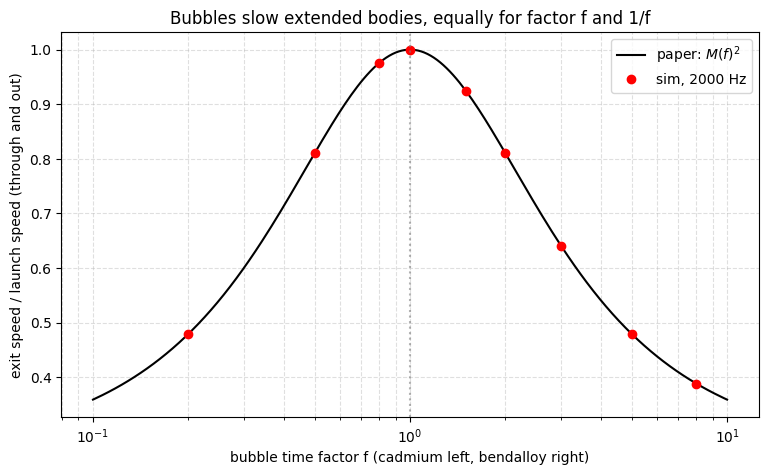

In [6]:
def slow_down_prediction(factor):
    crossing_multiplier = (1 + factor) ** 2 / (2 * (1 + factor ** 2))
    return crossing_multiplier ** 2   # in and back out

factors = [0.2, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
measured = []
print(f"{'factor':>7}  {'exit/launch':>12}  {'(1+f)^2/(2(1+f^2)) squared':>28}")
for factor in factors:
    turn, speed, _ = cross_bubble(RigidConstraint, 2000, time_factor=factor)
    measured.append(speed / LAUNCH_SPEED)
    print(f"{factor:7.1f}  {speed / LAUNCH_SPEED:12.4f}  {slow_down_prediction(factor):28.4f}")

curve_factors = np.logspace(np.log10(0.1), np.log10(10), 200)
plt.figure(figsize=(9, 5))
plt.semilogx(curve_factors, [slow_down_prediction(f) for f in curve_factors],
             "k-", label="paper: $M(f)^2$")
plt.semilogx(factors, measured, "ro", label="sim, 2000 Hz")
plt.axvline(1.0, color="gray", linestyle=":", alpha=0.6)
plt.xlabel("bubble time factor f (cadmium left, bendalloy right)")
plt.ylabel("exit speed / launch speed (through and out)")
plt.title("Bubbles slow extended bodies, equally for factor f and 1/f")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

## Part 4 - the tilted bullet

Parts 2 and 3 settled that an aligned bullet is never turned, at any tick
rate. The reason is geometric: every internal force acts along the rod, the
rod lies along the motion, and a force along the line of motion cannot turn
it. Does that kill the books' deflected bullets?

No, and the way out was in the draft's experiment-B plot: after the bubble,
the nose and tail traces separate, and two ends of a nose-first bullet
trace the same path unless the bullet is rotating. Elliott's argument at
the time, quoted: "maybe the bullet is rotating, not literally deflecting
UPON IMPACT ON THE BUBBLE [...] Couple that with air resistance and a
bullet moving now SIDEWAYS as it's tail and nose aren't following the
trajectory exactly, and I think we can call that subtle deflection." The
right definition of the books' deflection was never "a heading kick at the
boundary"; it is "the bullet misses." A boundary that spins bullets, in a
world with air, makes bullets miss.

This lab has no air yet (standing roadmap item). Here we measure the spin
half: fire bullets with deliberate tilt and watch the entry. Ground truth
rides along as the check. One note on realism: real shots always have some
tilt, because gravity curves the velocity during flight while nothing
rotates the rod, so by the time any real bullet reaches the boundary its
axis is slightly off its motion.


 tilt   entry kick (4 kHz)   ground truth   spin (truth)


   0 deg              +0.000 deg        +0.000 deg           0 deg/s


   1 deg              -0.444 deg        -0.444 deg         798 deg/s


   2 deg              -0.887 deg        -0.887 deg        1595 deg/s


   5 deg              -2.193 deg        -2.186 deg        3947 deg/s


  10 deg              -4.218 deg        -4.168 deg        7634 deg/s


  20 deg              -7.230 deg        -7.055 deg       13548 deg/s


  30 deg              -9.558 deg        -8.918 deg       17362 deg/s


  45 deg             -14.469 deg       -14.102 deg       19887 deg/s


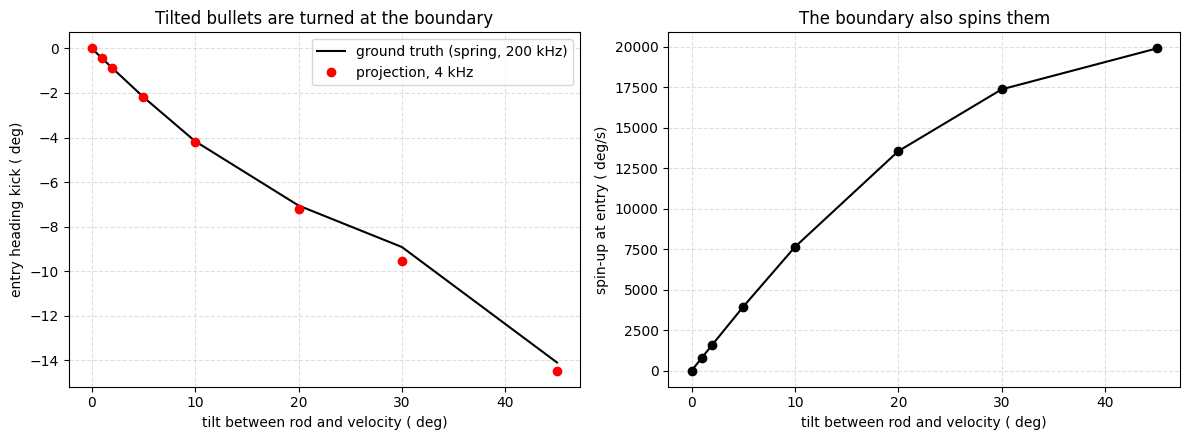

In [7]:
def entry_kick(tilt_deg, hz, use_spring=False, settle_seconds=0.004):
    """Measure the bullet just after BOTH ends are inside the bubble: the
    entry boundary's work is done, the exit boundary hasn't started. While
    fully inside, both ends share one clock, so the center-of-mass velocity is frozen
    and the measurement window is wide."""
    world = World(dt_seconds=1.0 / hz)
    if use_spring:
        nose, tail = spring_bullet(world, (0, 10), flight_deg=0,
                                   speed=LAUNCH_SPEED, tilt_deg=tilt_deg)
    else:
        nose, tail = make_bullet(world, (0, 10), flight_deg=0,
                                 speed=LAUNCH_SPEED, tilt_deg=tilt_deg)
    world.add_power(AntiGravity([nose, tail]))
    world.add_bubble(SpeedBubble(**BUBBLE))
    bubble_center = np.array(BUBBLE["center"], dtype=float)

    report_time = None
    for _ in range(int(0.2 * hz)):
        world.step()
        both_inside = all(np.linalg.norm(body.position - bubble_center) < 5
                          for body in (nose, tail))
        if both_inside and report_time is None:
            report_time = world.time_seconds + settle_seconds
        if report_time is not None and world.time_seconds >= report_time:
            break
    return bullet_state(nose, tail)


tilts = [0, 1, 2, 5, 10, 20, 30, 45]
projection_kicks, spring_kicks, spins = [], [], []
print(f"{'tilt':>5}  {'entry kick (4 kHz)':>19}  {'ground truth':>13}  {'spin (truth)':>13}")
for tilt in tilts:
    kick, _, _ = entry_kick(tilt, 4000)
    truth_kick, _, truth_spin = entry_kick(tilt, GROUND_TRUTH_HZ, use_spring=True)
    projection_kicks.append(kick)
    spring_kicks.append(truth_kick)
    spins.append(truth_spin)
    print(f"{tilt:4.0f} deg  {kick:+18.3f} deg  {truth_kick:+12.3f} deg  {truth_spin:10.0f} deg/s")

figure, (kick_axes, spin_axes) = plt.subplots(1, 2, figsize=(12, 4.5))
kick_axes.plot(tilts, spring_kicks, "k-", label="ground truth (spring, 200 kHz)")
kick_axes.plot(tilts, projection_kicks, "ro", label="projection, 4 kHz")
kick_axes.set_xlabel("tilt between rod and velocity ( deg)")
kick_axes.set_ylabel("entry heading kick ( deg)")
kick_axes.set_title("Tilted bullets are turned at the boundary")
kick_axes.legend()
kick_axes.grid(True, linestyle="--", alpha=0.4)
spin_axes.plot(tilts, spins, "k-o")
spin_axes.set_xlabel("tilt between rod and velocity ( deg)")
spin_axes.set_ylabel("spin-up at entry ( deg/s)")
spin_axes.set_title("The boundary also spins them")
spin_axes.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

The entry numbers settle and match ground truth: 10 deg of tilt buys about
-4.2 deg of real heading change, plus spin in the thousands of degrees per
second - the 20 cm bullet leaves the entry boundary turning at tens of
revolutions per second.

That spin sets up the last measurement. A bullet spinning at about 20
revolutions per second takes about 40 ms to cross the bubble - time enough
for the rod to swing through a large, effectively arbitrary angle. The
angle it happens to hold at the exit boundary decides the exit kick. So the
full trip should be deterministic (nothing in this engine is random) yet
unpredictable in practice: tiny changes to the entry conditions, or to the
tick rate, meet the exit at a different angle.


In [8]:
print("full transit, 10 deg tilt - same physics, different tick rates:")
for hz in [1000, 2000, 4000, 8000, 16000]:
    turn, speed, spin = cross_bubble(RigidConstraint, hz, flight_deg=0, tilt_deg=10)
    print(f"  {hz:5d} Hz: total heading change {turn:+9.3f} deg, "
          f"exit speed {speed:6.2f} m/s, exit spin {spin:7.0f} deg/s")

print()
print("full transit at 4000 Hz - tilt nudged by tenths of a degree:")
for tilt in [9.8, 9.9, 10.0, 10.1, 10.2]:
    turn, speed, spin = cross_bubble(RigidConstraint, 4000, flight_deg=0, tilt_deg=tilt)
    print(f"  tilt {tilt:5.1f} deg: total heading change {turn:+9.3f} deg, "
          f"exit speed {speed:6.2f} m/s, exit spin {spin:7.0f} deg/s")

full transit, 10 deg tilt - same physics, different tick rates:
   1000 Hz: total heading change   -10.897 deg, exit speed  26.31 m/s, exit spin    5125 deg/s
   2000 Hz: total heading change    -1.589 deg, exit speed  31.67 m/s, exit spin     410 deg/s
   4000 Hz: total heading change    -9.648 deg, exit speed  32.88 m/s, exit spin    3109 deg/s
   8000 Hz: total heading change    -4.728 deg, exit speed  28.70 m/s, exit spin    1826 deg/s


  16000 Hz: total heading change    -8.893 deg, exit speed  32.48 m/s, exit spin    5258 deg/s

full transit at 4000 Hz - tilt nudged by tenths of a degree:
  tilt   9.8 deg: total heading change    -4.143 deg, exit speed  33.85 m/s, exit spin    2757 deg/s
  tilt   9.9 deg: total heading change    -4.181 deg, exit speed  33.83 m/s, exit spin    2760 deg/s
  tilt  10.0 deg: total heading change    -9.648 deg, exit speed  32.88 m/s, exit spin    3109 deg/s
  tilt  10.1 deg: total heading change    -8.328 deg, exit speed  32.91 m/s, exit spin    3342 deg/s
  tilt  10.2 deg: total heading change    -9.549 deg, exit speed  32.47 m/s, exit spin    3473 deg/s


The entry settles; the full trip scatters. This time the scatter is
physics, not a bug: the exit meets the bullet's spin at an angle no
practical tick rate can pin down. The check that separates the two cases:
the entry measurement agrees with ground truth at every tick rate (so the
instrument is sound), while the full trip depends on a fast internal motion
(so the sensitivity is real).

## Findings

1. **An aligned rigid bullet is never turned by a bubble boundary.** All
   internal forces act along the rod and the rod lies along the motion.
   Measured zero at every tick rate; ground truth agrees.
2. **Bubbles slow extended bodies.** Each crossing multiplies stored speed
   by M(f) = (1+f)^2 / (2(1+f^2)), which is at most 1 and equal for f and
   1/f - cadmium slows a bullet exactly like bendalloy. A 5x bubble
   in-and-out leaves 48% of launch speed. World-frame momentum is not
   conserved at boundaries for extended bodies; the bubble absorbs the
   difference (model property, stated).
3. **Tilted bullets turn and spin.** 10 deg of tilt gives a settled,
   ground-truth-matched -4.2 deg heading change at entry, plus thousands of
   deg/s of spin. The exit then depends on the spin angle, so the total
   deflection is deterministic but unpredictable in practice - which is how
   the books describe it. Real shots always arrive slightly tilted.
4. **Spin plus air equals a miss** (Elliott's argument, quoted in part 4).
   Air drag is the one missing piece, and it is now load-bearing for two
   phenomena: Skimmer safe-falling (notebook 10) and bullet deflection.
5. **Engine rule:** boundary shear needs dt < rod length / (speed *
   factor); at 240 Hz fast bullets skip it. Otherwise the corrected
   constraint is exact at any tick rate.
6. **Method notes.** The draft's failure was raising the tick rate until
   the effect appeared, then stopping. The checks that caught it - the
   right control, gravity-off heading measurement, tick-rate sweep,
   spawn-point shifts, independent ground truth - are house standard for
   boundary physics now. Probe checks pin findings 1-3.

Next: notebook 12B - the wide bullet. Width turns out to remove even the
need for tilt. After that: air drag.
